# Customer segmentation clustering problem

In [106]:
#import the necessary lib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

### Data loading and inspection

In [107]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [108]:
df.shape

(200, 5)

In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [110]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [111]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

- The dataset has 200 observations with 5 features
- no null value
- datatype are also consistent
- Typical age of customer is around 38.85
- std of Annual income and spending score shows that data might not really spread out. Mean is also close to the middle value, distribution may be normal

### Visualisation of distribution

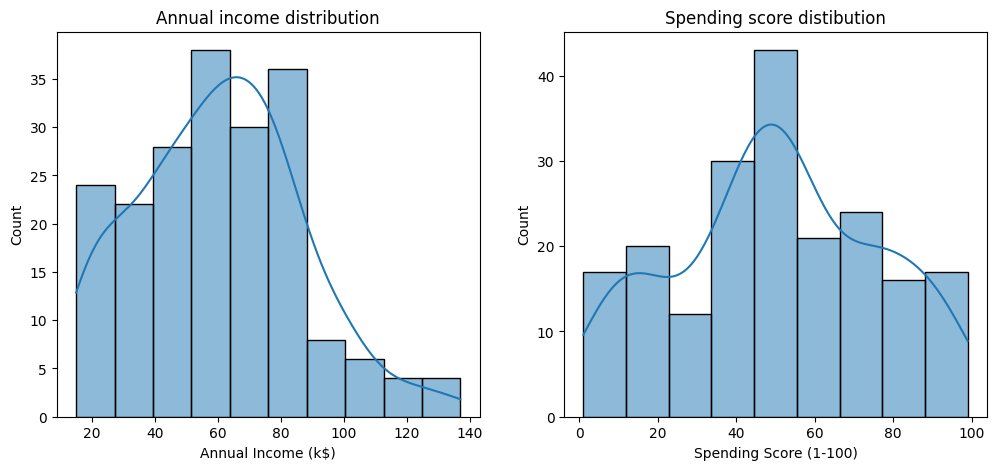

In [112]:
# we visualise the two important feature which are the annual income, and spending score

plt.figure(figsize=(12,5))

#annual income
plt.subplot(1,2,1)
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title('Annual income distribution')

#spending score
plt.subplot(1,2,2)
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title('Spending score distibution')
plt.show()

## Feature selection and scaling
-always scale your data before clustering algorithm

In [113]:
# select the most important features, remember this is an unsupervised learning.
# no label feature

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

#view the X features
X.head()


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [114]:
# scaling the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#view the scaled X
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

##### K mean requires us to know the number of clusters which is the K, so we need to dtermine the optimum number using the elbow method

In [115]:
#To find optimal k
wcss = [] #within cluster sum of square

for k in range (1,11):
    kmeans = KMeans(n_clusters = k, random_state = 234)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [116]:
wcss

[399.99999999999994,
 270.70426664306717,
 195.2466301907915,
 108.92131661364357,
 65.56840815571681,
 55.057348270386,
 46.80995783413121,
 42.871289711022854,
 32.40665967645661,
 30.028327639008268]

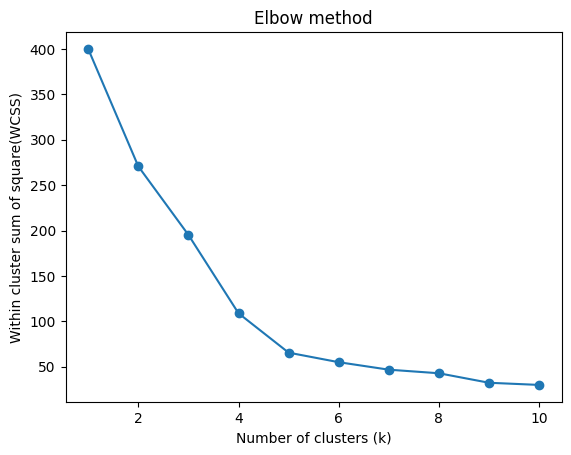

In [117]:
plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within cluster sum of square(WCSS)')
plt.title('Elbow method')
plt.show()

### Training K-Means model

- from the elbow method, we now know that our optimal k value is 5

In [118]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [119]:
#df = df.drop(columns='clusters')

In [120]:
df['Clusters'] = clusters
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


- We now have our clusters (customer segmentation)

### We can now visualise the clusters

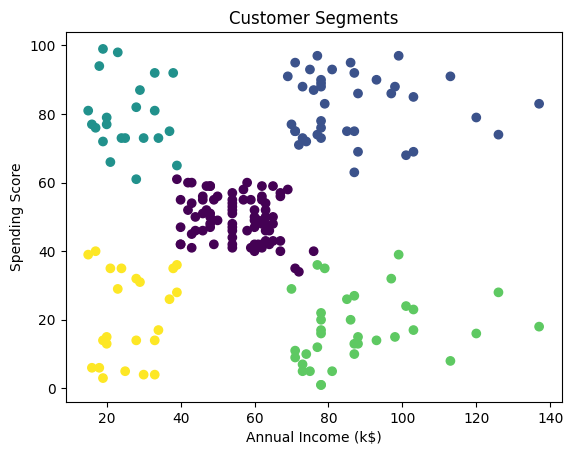

In [121]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Clusters'])

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

### Profile numerical cluster

In [122]:
df.groupby('Clusters')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Clusters,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [123]:
df['Clusters'].value_counts()

Clusters
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

### K means model evaluation

In [124]:
# using silhouette
score = silhouette_score(X_scaled, df['Clusters'])
score

0.5546571631111091

## Anomaly detection 
- Using isolation forest algorithm (Anomalies are easier to isolate than normal points)

- finding data points that don’t belong well to any cluster 

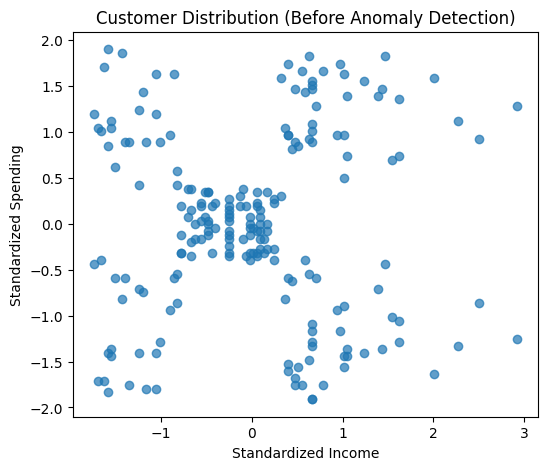

In [125]:
#visualise the  X_scaled before anomaly
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.7)
#alpha adjust transparency of the data points

plt.xlabel("Standardized Income")
plt.ylabel("Standardized Spending")
plt.title("Customer Distribution (Before Anomaly Detection)")
plt.show()

### Isolation forest algorithm

In [127]:
from sklearn.ensemble import IsolationForest

#dfine the model
iso = IsolationForest(n_estimators=100, contamination=0.05 , random_state=42)
# n_estimators: number of trees. more treess = more stability
#contamination assumes ~5% anomalies, adjust later

#fit the model
iso.fit(X_scaled)

iso_predict = iso.predict(X_scaled) #predict

#add to dataframe
df['Anomaly_iso'] = iso_predict

In [128]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters,Anomaly_iso
0,1,Male,19,15,39,4,1
1,2,Male,21,15,81,2,1
2,3,Female,20,16,6,4,1
3,4,Female,23,16,77,2,1
4,5,Female,31,17,40,4,1


In [129]:
#anomaly count
df['Anomaly_iso'].value_counts()

Anomaly_iso
 1    190
-1     10
Name: count, dtype: int64

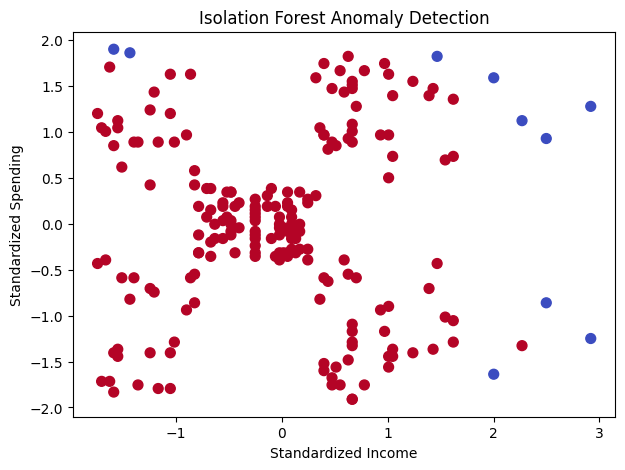

In [132]:
#visualise the anomaly
plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Anomaly_iso'], cmap = 'coolwarm', s = 50)

plt.xlabel("Standardized Income")
plt.ylabel("Standardized Spending")
plt.title("Isolation Forest Anomaly Detection")
plt.show()

In [135]:
# filtring the anomalies
anomalies = df[df['Anomaly_iso'] == -1]

#inspect other features with the abomalies
anomalies.head(20)
#or

anomalies[['Annual Income (k$)', 'Spending Score (1-100)']]

,Annual Income (k$),Spending Score (1-100)
11,19,99
19,23,98
185,99,97
192,113,8
193,113,91
195,120,79
196,126,28
197,126,74
198,137,18
199,137,83


### Creating Dendogram, using hierachical model
- agglomerativeclustering algorithm (most commonly used, from bottom to top)

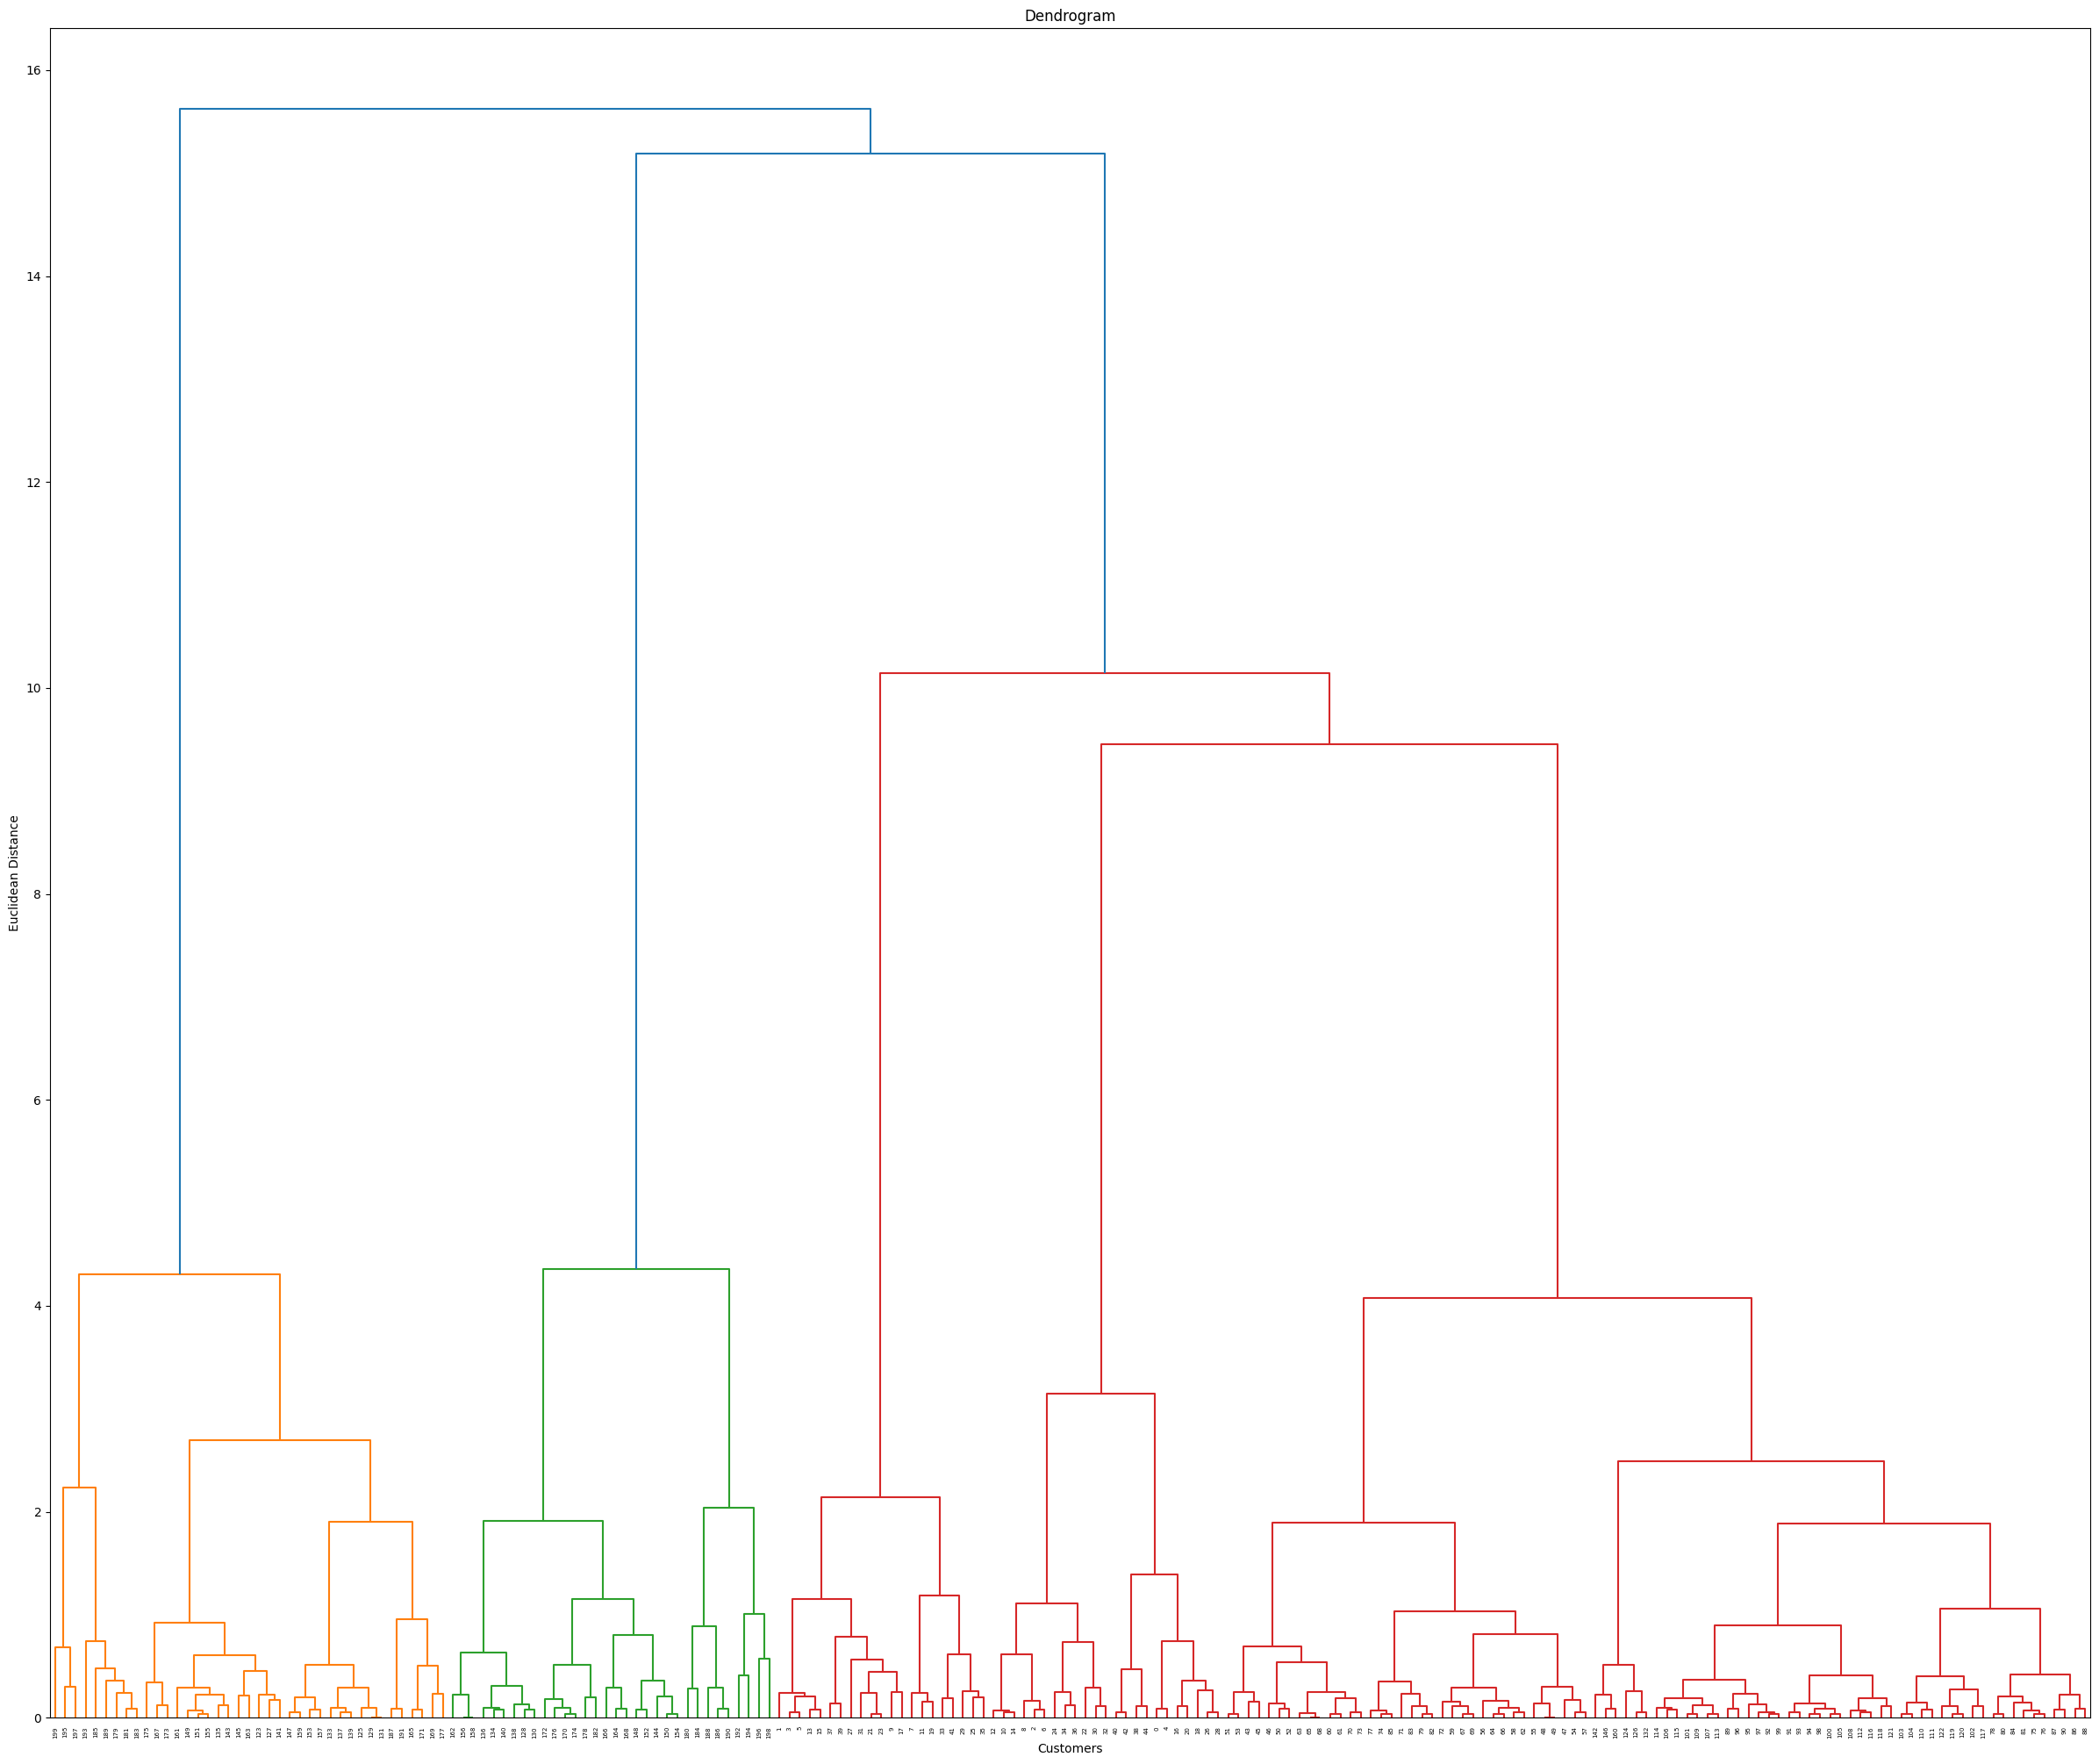

In [137]:
plt.figure(figsize=(30,25))

dendrogram(linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

- Training the model
-
 n_clusters is chosen from the dendogram

In [138]:
hie_c = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

hc = hie_c.fit_predict(X_scaled)

In [139]:
#add hieracical clustering to the dataframe

df['Hierarchichal_cluster'] = hc

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters,Anomaly_iso,Hierarchichal_cluster
0,1,Male,19,15,39,4,1,0
1,2,Male,21,15,81,2,1,0
2,3,Female,20,16,6,4,1,0
3,4,Female,23,16,77,2,1,0
4,5,Female,31,17,40,4,1,0


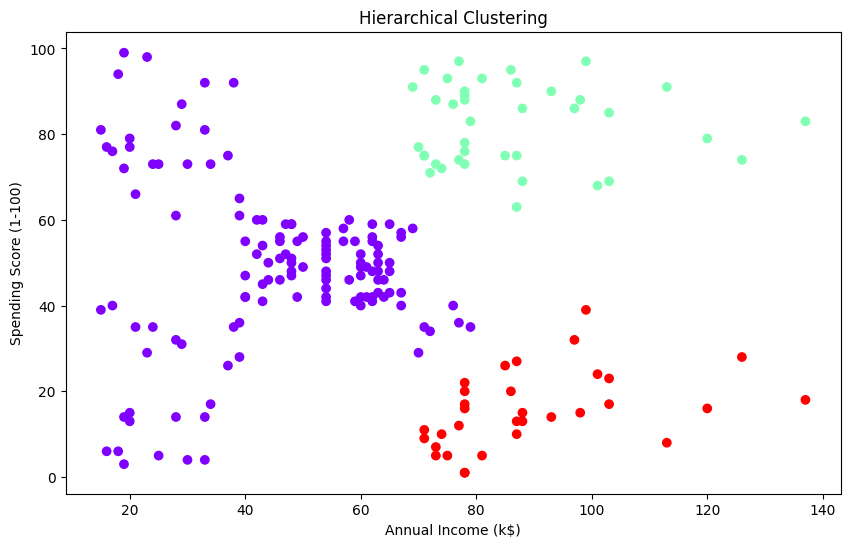

In [140]:
#visualising the HC
plt.figure(figsize=(10,6))
plt.scatter(
            df['Annual Income (k$)'], 
            df['Spending Score (1-100)'], 
            c=df['Hierarchichal_cluster'], 
            cmap='rainbow'
            )

plt.title('Hierarchical Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

#### Evaluating the cluster using silhouette score

In [142]:
hc_sil = silhouette_score(X_scaled, hc)
print('Silhouette score is:', hc_sil)

Silhouette score is: 0.4610481446570447


In [146]:
#group by

df.groupby('Hierarchichal_cluster')[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

,Annual Income (k$),Spending Score (1-100)
Hierarchichal_cluster,,
0,45.550388,49.131783
1,86.538462,82.128205
2,89.406250,15.593750


#### The end of clustering unsupervised learning problem

- In this notebook, KMeans, isolation forest and agglomerative clustering algorithm were treated.
- The performance of the models can be improved by tuning the model parameters